### 1. **Setup and Data Loading**

This first section loads the necessary R packages and the data files from your previous DESeq2 analysis.

In [ ]:
### Cell 1: Setup and Library Loading
# Install packages if you don't have them
if (!requireNamespace("BiocManager", quietly = TRUE))
    install.packages("BiocManager")
if (!requireNamespace("tidyverse", quietly = TRUE))
    install.packages("tidyverse")
if (!requireNamespace("ggplot2", quietly = TRUE))
    install.packages("ggplot2")
if (!requireNamespace("ggrepel", quietly = TRUE))
    install.packages("ggrepel")
if (!requireNamespace("pheatmap", quietly = TRUE))
    install.packages("pheatmap")
if (!requireNamespace("AnnotationDbi", quietly = TRUE))
    BiocManager::install("AnnotationDbi")
if (!requireNamespace("org.Hs.eg.db", quietly = TRUE)) # Example for Human
    BiocManager::install("org.Hs.eg.db")
if (!requireNamespace("apeglm", quietly = TRUE)) 
    BiocManager::install("apeglm")
if (!requireNamespace("EnhancedVolcano", quietly = TRUE)) 
    BiocManager::install("EnhancedVolcano")

# Load libraries
suppressPackageStartupMessages({
library(tidyverse)
library(ggplot2)
library(ggrepel)
library(pheatmap)
library(AnnotationDbi)
library(org.Hs.eg.db)
library(DESeq2)
library(EnhancedVolcano)
library(glue)
})


# Set a seed for reproducibility
set.seed(42)

In [12]:
dds <- readRDS("output/deseq2/dds.rds")
metadata = read.csv("metadata.csv", row.names=1)

In [13]:
### Cell 2: Extract Results
res <- DESeq2::results(dds)

In [14]:
str(res, 2)

Formal class 'DESeqResults' [package "DESeq2"] with 7 slots
  ..@ priorInfo      : list()
  ..@ rownames       : chr [1:60675] "ENSG00000223972" "ENSG00000227232" "ENSG00000278267" "ENSG00000243485" ...
  ..@ nrows          : int 60675
  ..@ elementType    : chr "ANY"
  ..@ elementMetadata:Formal class 'DFrame' [package "S4Vectors"] with 6 slots
  ..@ metadata       :List of 6
  ..@ listData       :List of 6


In [15]:
# 5. Extract and Process Results
# ----------------------------------------------------------- #
# Extract results for a specific contrast (e.g., 'treated' vs 'control')
# The contrast specifies the levels to compare, in the order 'numerator' vs 'denominator'.
results_table <- results(dds, contrast = c("condition", "CN", "AD"))
results_table_df <- as.data.frame(results_table)


In [16]:
colnames(results_table_df)

[1] "baseMean"       "log2FoldChange" "lfcSE"          "stat"          
[5] "pvalue"         "padj"

In [17]:

# Order results by padj (adjusted p-value)
results_table_df <- results_table_df[order(results_table_df$padj), ]
# results_shrunk_df <- results_shrunk_df[order(results_shrunk_df$padj), ]


In [34]:
colData(vsd)$line_no <- as.factor(colData(dds)$line_no) 

In [35]:

# 6. Quality Control and Visualization
# ----------------------------------------------------------- #
# Optional: Transform data for visualization
vsd <- vst(dds, blind = FALSE) # Variance stabilizing transformation
rld <- rlog(dds, blind = FALSE) # Regularized log transformation


In [36]:

plot_var <- c("condition", "sex", "line_no", "line_no_and_clone")  |> 
set_names()

pca_plots <- map(plot_var, ~{plotPCA(vsd, intgroup = .x) + labs(title = glue("PCA - {.x}"))})


using ntop=500 top features by variance

using ntop=500 top features by variance



using ntop=500 top features by variance

using ntop=500 top features by variance



In [ ]:
pdf("results/pca_plots.pdf")
print(pca_plots)
dev.off()

$condition



$sex

$line_no

$line_no_and_clone



png 
  2

: 

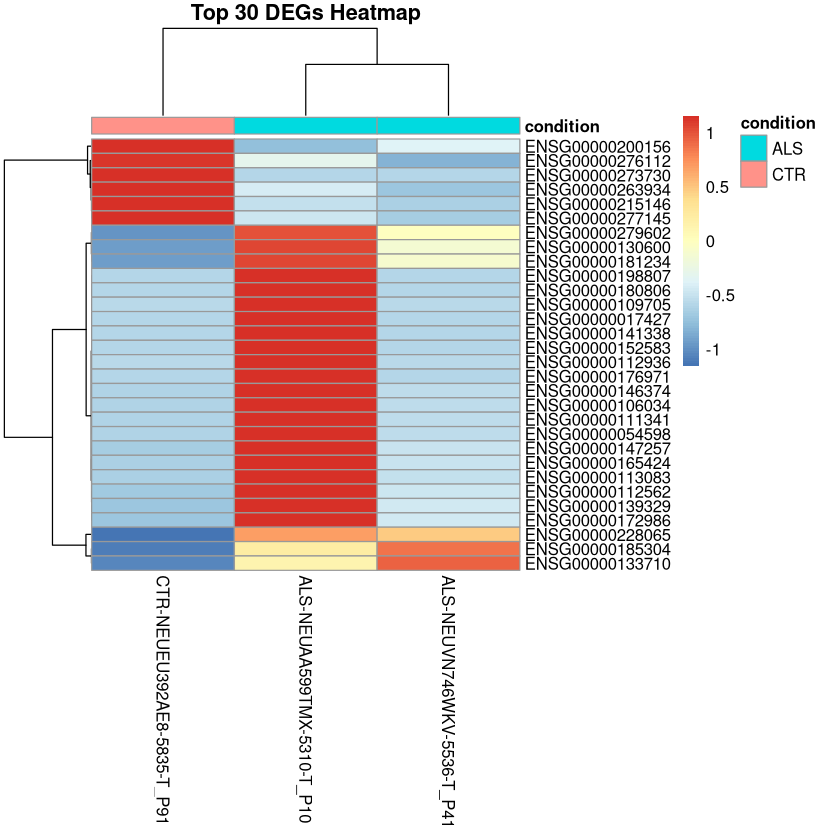

In [62]:

# Heatmap of the top differentially expressed genes
top_genes <- head(rownames(results_table_df), 30)
top_genes_matrix <- assay(vsd)[top_genes, ]


heatmap <- ggplotify::as.ggplot(pheatmap(top_genes_matrix, scale = "row", clustering_distance_rows = "correlation", 
         clustering_distance_cols = "correlation", main = "Top 30 DEGs Heatmap",
         annotation_col = data.frame(condition = metadata$condition, row.names = rownames(metadata))))



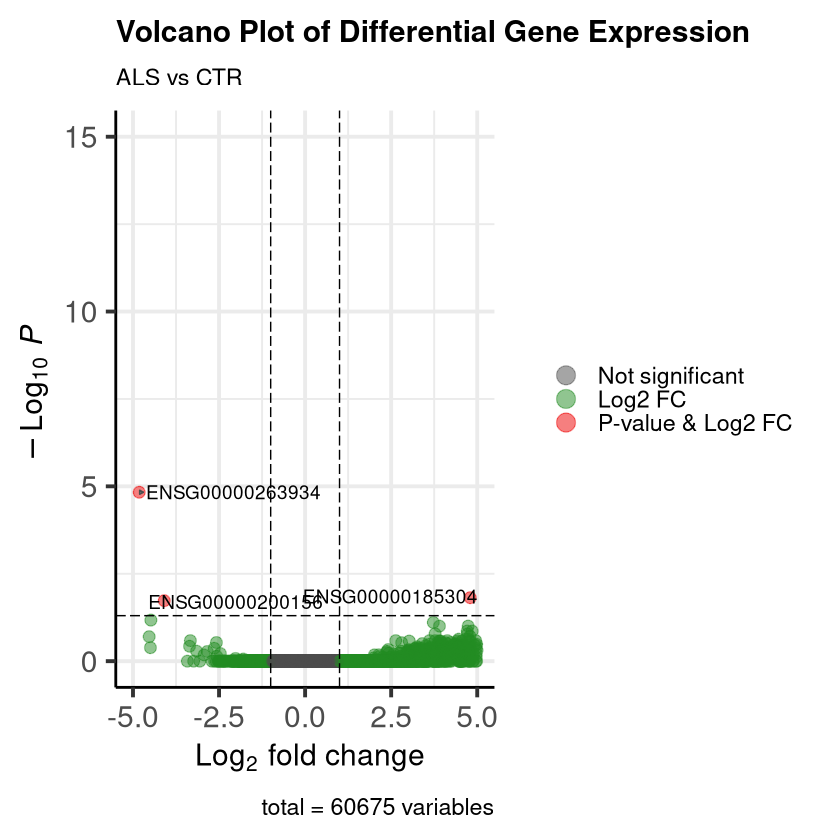

In [ ]:
# EnhancedVolcano requires row names for gene labels
# Ensure your data frame has gene names as row names

# Create the plot
EnhancedVolcano(
  results_table_df,
  lab = rownames(results_table_df),
  x = 'log2FoldChange',
  y = 'padj',
  title = 'Volcano Plot of Differential Gene Expression',
  pCutoff = 0.05, # Adjusted p-value cutoff
  FCcutoff = 1.0, # Log2 fold change cutoff
  pointSize = 3.0,
  labSize = 4.0,
  xlim = c(-5, 5), # Set custom x-axis limits
  ylim = c(0, 15), # Set custom y-axis limits
  subtitle = 'ALS vs CTR',
  legendPosition = 'right',
  legendLabels = c('Not significant', 'Log2 FC', 'P-value', 'P-value & Log2 FC'),
  drawConnectors = TRUE,
  widthConnectors = 0.5,
  colConnectors = 'grey30'
)

In [64]:

# 7. Save Final Results
# ----------------------------------------------------------- #
# Create an output directory if it doesn't exist
dir.create("results/deseq2", showWarnings = FALSE)

# Save the full results tables
write_csv(results_table_df, "results/deseq2/full_results.csv")
# write_csv(results_shrunk_df, "results/deseq2/lfc_shrunk_results.csv")

# Save key plots
ggsave("results/deseq2/pca_plot.png", plot = pca_plot)

# Save key plots
ggsave("results/deseq2/heatmap.png", plot = heatmap)

# Final message
print("Analysis complete. Results and plots saved to the 'results' directory.")

# Print session info for reproducibility
sessionInfo()

Saving 7 x 7 in image
Saving 7 x 7 in image


[1] "Analysis complete. Results and plots saved to the 'results' directory."


R version 4.4.2 (2024-10-31)
Platform: x86_64-pc-linux-gnu
Running under: Rocky Linux 9.6 (Blue Onyx)

Matrix products: default
BLAS/LAPACK: /opt/apps/OpenBLAS/0.3.26/lib/libopenblas_haswellp-r0.3.26.so;  LAPACK version 3.12.0

locale:
[1] C

time zone: America/Los_Angeles
tzcode source: internal

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] EnhancedVolcano_1.24.0      DESeq2_1.46.0              
 [3] SummarizedExperiment_1.36.0 MatrixGenerics_1.18.0      
 [5] matrixStats_1.4.1           GenomicRanges_1.58.0       
 [7] GenomeInfoDb_1.42.0         org.Hs.eg.db_3.20.0        
 [9] AnnotationDbi_1.68.0        IRanges_2.40.0             
[11] S4Vectors_0.44.0            Biobase_2.66.0             
[13] BiocGenerics_0.52.0         pheatmap_1.0.13            
[15] ggrepel_0.9.6               lubridate_1.9.3            
[17] forcats_1.0.0               stringr_1.5.1              
[19] dplyr_1.1

___
### 4. **Gene Annotation and Final Export**

This final section adds biological context to your gene IDs and saves the annotated results for sharing.

In [50]:
rownames(results_table_df)

[1] "ENSG00000273730" "ENSG00000215146" "ENSG00000263934" "ENSG00000130600"
    [5] "ENSG00000181234" "ENSG00000139329" "ENSG00000185304" "ENSG00000200156"
    [9] "ENSG00000111341" "ENSG00000054598" "ENSG00000112936" "ENSG00000165424"
   [13] "ENSG00000146374" "ENSG00000112562" "ENSG00000277145" "ENSG00000279602"
   [17] "ENSG00000176971" "ENSG00000147257" "ENSG00000113083" "ENSG00000276112"
   [21] "ENSG00000152583" "ENSG00000228065" "ENSG00000133710" "ENSG00000141338"
   [25] "ENSG00000106034" "ENSG00000017427" "ENSG00000172986" "ENSG00000109705"
   [29] "ENSG00000180806" "ENSG00000198807" "ENSG00000163638" "ENSG00000169908"
   [33] "ENSG00000109193" "ENSG00000180772" "ENSG00000137693" "ENSG00000151702"
   [37] "ENSG00000103888" "ENSG00000176046" "ENSG00000259974" "ENSG00000171812"
   [41] "ENSG00000215559" "ENSG00000116729" "ENSG00000003436" "ENSG00000113721"
   [45] "ENSG00000112559" "ENSG00000112280" "ENSG00000146250" "ENSG00000076716"
   [49] "ENSG00000213694" "ENSG00000185201" "ENSG00000011465" "ENSG00000109099"
   [53] "ENSG00000111145" "ENSG00000043355" "ENSG00000075651" "ENSG00000135272"
   [57] "ENSG00000111087" "ENSG00000130635" "ENSG00000205611" "ENSG00000166292"
   [61] "ENSG00000163513" "ENSG00000163191" "ENSG00000143248" "ENSG00000144649"
   [65] "ENSG00000170312" "ENSG00000124942" "ENSG00000135046" "ENSG00000080493"
   [69] "ENSG00000116774" "ENSG00000263503" "ENSG00000132854" "ENSG00000182492"
   [73] "ENSG00000229807" "ENSG00000126778" "ENSG00000145431" "ENSG00000198121"
   [77] "ENSG00000084636" "ENSG00000152104" "ENSG00000143867" "ENSG00000049323"
   [81] "ENSG00000152689" "ENSG00000164616" "ENSG00000092607" "ENSG00000188153"
   [85] "ENSG00000124145" "ENSG00000129514" "ENSG00000031081" "ENSG00000137962"
   [89] "ENSG00000066279" "ENSG00000174963" "ENSG00000179344" "ENSG00000164434"
   [93] "ENSG00000223414" "ENSG00000128510" "ENSG00000156925" "ENSG00000065717"
   [97] "ENSG00000278558" "ENSG00000024526" "ENSG00000168743" "ENSG00000162692"
  [101] "ENSG00000162623" "ENSG00000173193" "ENSG00000145794" "ENSG00000124782"
  [105] "ENSG00000132561" "ENSG00000109861" "ENSG00000184232" "ENSG00000224597"
  [109] "ENSG00000069431" "ENSG00000087303" "ENSG00000128849" "ENSG00000176692"
  [113] "ENSG00000177469" "ENSG00000075643" "ENSG00000107249" "ENSG00000155324"
  [117] "ENSG00000060718" "ENSG00000134250" "ENSG00000143341" "ENSG00000109758"
  [121] "ENSG00000204291" "ENSG00000174807" "ENSG00000116791" "ENSG00000214617"
  [125] "ENSG00000196187" "ENSG00000107562" "ENSG00000144857" "ENSG00000134363"
  [129] "ENSG00000189129" "ENSG00000102024" "ENSG00000221869" "ENSG00000106571"
  [133] "ENSG00000104213" "ENSG00000181019" "ENSG00000100504" "ENSG00000131724"
  [137] "ENSG00000162407" "ENSG00000081803" "ENSG00000137834" "ENSG00000168461"
  [141] "ENSG00000278530" "ENSG00000182718" "ENSG00000183090" "ENSG00000198075"
  [145] "ENSG00000122592" "ENSG00000196411" "ENSG00000135476" "ENSG00000189184"
  [149] "ENSG00000138080" "ENSG00000198203" "ENSG00000162804" "ENSG00000260518"
  [153] "ENSG00000189229" "ENSG00000166106" "ENSG00000138119" "ENSG00000139800"
  [157] "ENSG00000215845" "ENSG00000117318" "ENSG00000155011" "ENSG00000157483"
  [161] "ENSG00000074181" "ENSG00000165186" "ENSG00000109805" "ENSG00000112902"
  [165] "ENSG00000041982" "ENSG00000135750" "ENSG00000154175" "ENSG00000163453"
  [169] "ENSG00000269936" "ENSG00000198959" "ENSG00000162733" "ENSG00000071205"
  [173] "ENSG00000101425" "ENSG00000102287" "ENSG00000162267" "ENSG00000250786"
  [177] "ENSG00000251493" "ENSG00000061455" "ENSG00000134954" "ENSG00000129474"
  [181] "ENSG00000172575" "ENSG00000140563" "ENSG00000152284" "ENSG00000076770"
  [185] "ENSG00000260776" "ENSG00000103241" "ENSG00000172123" "ENSG00000114251"
  [189] "ENSG00000173714" "ENSG00000123700" "ENSG00000090339" "ENSG00000261599"
  [193] "ENSG00000082438" "ENSG00000124813" "ENSG00000170962" "ENSG00000158270"
  [197] "ENSG00000198682" "ENSG00000145358" "ENSG00000120156" "ENSG00000140092"
  [2

In [51]:
### Cell 6: Annotate Genes
# Add a Gene_ID column to your results for joining
results_table_df <- results_table_df %>%
  as_tibble(rownames = "Gene_ID")

# Get gene symbols from the annotation database
tryCatch({
  annotated_genes <- AnnotationDbi::mapIds(
    x = org.Hs.eg.db,
    keys = results_table_df$Gene_ID,
    column = "SYMBOL",
    keytype = "ENSEMBL", # Change this keytype based on your organism's IDs
    multiVals = "first"
  )
  
  # Add the gene symbols to the results data frame
  results_table_df$Gene_Symbol <- annotated_genes

}, error = function(e) {
  message("Annotation failed. Check your gene IDs and keytype.")
  print(e)
})

'select()' returned 1:many mapping between keys and columns

